# 00 · Prepare VisDrone once

Run all cells. The notebook is idempotent: verified archives, extraction,
conversion, and LR-search manifests are reused. Raw VisDrone data is never
modified. The controlled workflow prepares only the 2-class track by default.


In [1]:
USE_GOOGLE_DRIVE = True
DATASET_SOURCE = "auto"
PREPARE_10CLASS_TRACK = False
REDOWNLOAD = False
SMOKE_TEST = False


In [2]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
SMOKE_TEST = SMOKE_TEST or os.environ.get("SMOKE_TEST", "").lower() in {"1", "true", "yes"}
if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

REPO_PATH = Path("/content/aerial-object-detection-benchmark") if IN_COLAB else Path.cwd()
REPOSITORY_URL = "https://github.com/Harryphan72007/aerial-object-detection-benchmark.git"
if IN_COLAB:
    if not (REPO_PATH / ".git").is_dir():
        subprocess.run(["git", "clone", "--branch", "main", REPOSITORY_URL, str(REPO_PATH)], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO_PATH), "status", "--porcelain"], check=True)
        if subprocess.check_output(["git", "-C", str(REPO_PATH), "status", "--porcelain"], text=True).strip():
            raise RuntimeError("Repository has local changes; refusing to update it.")
        subprocess.run(["git", "-C", str(REPO_PATH), "pull", "--ff-only", "origin", "main"], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(REPO_PATH / "requirements-dataset-colab.txt")],
        check=True,
    )
sys.path.insert(0, str(REPO_PATH))

if SMOKE_TEST:
    DRIVE_ROOT = REPO_PATH / ".notebook-smoke" / "dataset"
else:
    DRIVE_ROOT = (
        Path("/content/drive/MyDrive/visdrone_architecture_benchmark")
        if IN_COLAB and USE_GOOGLE_DRIVE
        else Path(os.environ.get("VISDRONE_DRIVE_ROOT", REPO_PATH / "local_artifacts"))
    )
print(f"Execution: {'Colab' if IN_COLAB else 'local'}")
print(f"Repository: {REPO_PATH}")
print(f"Persistent root: {DRIVE_ROOT}")


Mounted at /content/drive
Execution: Colab
Repository: /content/aerial-object-detection-benchmark
Persistent root: /content/drive/MyDrive/visdrone_architecture_benchmark


In [3]:
if SMOKE_TEST:
    from src.data.download import VISDRONE_ARCHIVES
    from src.data.smoke_dataset import create_smoke_archives
    archive_dir = DRIVE_ROOT / "datasets" / "VisDrone2019-DET" / "archives"
    create_smoke_archives(archive_dir)
    smoke_manifest_dir = DRIVE_ROOT / "datasets" / "VisDrone2019-DET" / "manifests"
    for split in VISDRONE_ARCHIVES:
        (smoke_manifest_dir / f"{split}_archive.json").unlink(missing_ok=True)
        (smoke_manifest_dir / f"{split}_extraction.json").unlink(missing_ok=True)
    for spec in VISDRONE_ARCHIVES.values():
        spec["minimum_bytes"] = 1

if DATASET_SOURCE == "manual" and IN_COLAB:
    from src.data.download import VISDRONE_ARCHIVES, manual_archive_instructions
    archive_dir = DRIVE_ROOT / "datasets" / "VisDrone2019-DET" / "archives"
    missing = [
        str(spec["filename"])
        for spec in VISDRONE_ARCHIVES.values()
        if not (archive_dir / str(spec["filename"])).is_file()
    ]
    if missing:
        print(manual_archive_instructions(archive_dir))
        from google.colab import files
        uploaded = files.upload()
        archive_dir.mkdir(parents=True, exist_ok=True)
        for filename, content in uploaded.items():
            if filename in missing:
                (archive_dir / filename).write_bytes(content)

from src.workflows.dataset_setup import prepare_visdrone
summary = prepare_visdrone(
    REPO_PATH,
    DRIVE_ROOT,
    dataset_source=DATASET_SOURCE,
    prepare_10class_track=PREPARE_10CLASS_TRACK,
    redownload=REDOWNLOAD,
    smoke_test=SMOKE_TEST,
)


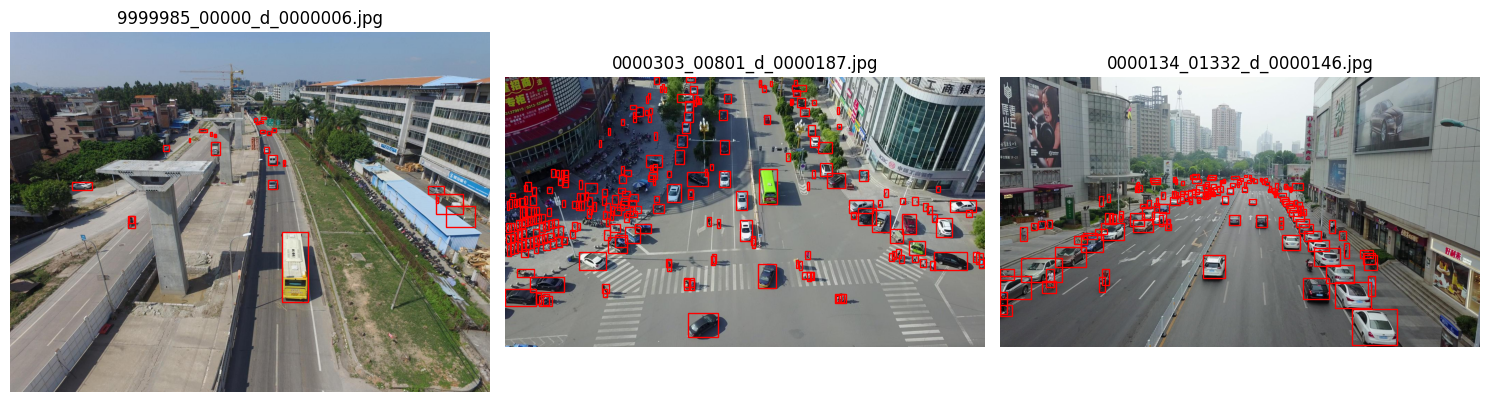

DataLoader smoke test: READY


In [4]:
import json
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from src.data.dataloaders import CocoDetectionRecords, detection_collate

coco_root = Path(summary["coco_2class"])
records = CocoDetectionRecords(Path(summary["train_images"]), coco_root / "annotations" / "instances_train.json")
indices = random.Random(42).sample(range(len(records)), min(3, len(records)))
figure, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 4))
axes = [axes] if len(indices) == 1 else axes
for axis, index in zip(axes, indices):
    item = records[index]
    axis.imshow(item["image"])
    for annotation in item["annotations"]:
        x, y, width, height = annotation["bbox"]
        axis.add_patch(Rectangle((x, y), width, height, fill=False, edgecolor="red", linewidth=1))
    axis.set_title(item["file_name"])
    axis.axis("off")
plt.tight_layout()
plt.show()

try:
    from torch.utils.data import DataLoader
    batch = next(iter(DataLoader(records, batch_size=2, shuffle=False, collate_fn=detection_collate)))
except ImportError:
    batch = detection_collate([records[0], records[min(1, len(records) - 1)]])
assert len(batch) == 2 and all("image" in item and "annotations" in item for item in batch)
print("DataLoader smoke test: READY")


In [5]:
contract = summary["data_contract"]
if not contract["verified"]:
    raise RuntimeError("DATA CONTRACT VERIFIED: NO")
details = contract["details"]
print("DATA CONTRACT VERIFIED: YES")
print()
print(f"Persistent Drive root: {summary['drive_root']}")
print(f"Train archive: {details['paths']['train_archive']}")
print(f"Validation archive: {details['paths']['validation_archive']}")
print(f"Train images: {summary['train_images']}")
print(f"Validation images: {summary['validation_images']}")
print(f"Train image count: {details['extractions']['train']['recorded']['image_count']}")
print(f"Validation image count: {details['extractions']['val']['recorded']['image_count']}")
print(f"COCO train: {details['paths']['coco_train']}")
print(f"COCO validation: {details['paths']['coco_validation']}")
print(f"LR-search manifests: {summary['lr_search_manifests']}")
print("Local-cache status: NOT ENABLED IN NOTEBOOK 00")
print("Next notebook: 01_run_model_day.ipynb")
print("https://colab.research.google.com/github/Harryphan72007/aerial-object-detection-benchmark/blob/main/notebooks/01_run_model_day.ipynb")


DATA CONTRACT VERIFIED: YES

Persistent Drive root: /content/drive/MyDrive/visdrone_architecture_benchmark
Train archive: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/archives/VisDrone2019-DET-train.zip
Validation archive: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/archives/VisDrone2019-DET-val.zip
Train images: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/raw/VisDrone2019-DET-train/images
Validation images: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/raw/VisDrone2019-DET-val/images
Train image count: 6471
Validation image count: 548
COCO train: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/processed/coco_2class/annotations/instances_train.json
COCO validation: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/processed/coco_2class/annotations/instances_val.json
LR-search mani